<a href="https://colab.research.google.com/github/mithun30052001/capstone-project/blob/main/Part1-Data-Acquisition-Cleaning-and-Explanatory-Analysis/Data_Prep_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Download the file directly to Colab
!wget -O complaints.csv.zip "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

# Unzip it
!unzip complaints.csv.zip

--2026-07-13 12:16:28--  https://files.consumerfinance.gov/ccdb/complaints.csv.zip
Resolving files.consumerfinance.gov (files.consumerfinance.gov)... 23.0.162.39, 23.0.162.49, 2600:1408:ec00:2f::1735:b89, ...
Connecting to files.consumerfinance.gov (files.consumerfinance.gov)|23.0.162.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1411523246 (1.3G) [binary/octet-stream]
Saving to: ‘complaints.csv.zip’

complaints.csv.zip  100%[===================>]   1.31G  41.9MB/s    in 36s     

2026-07-13 12:17:04 (37.8 MB/s) - ‘complaints.csv.zip’ saved [1411523246/1411523246]

Archive:  complaints.csv.zip
  inflating: complaints.csv          


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Load the dataset from the zipped CSV
# Assuming the file is uploaded to your Colab session as 'complaints.csv.zip'
print("Loading dataset...")
df = pd.read_csv('complaints.csv', low_memory=False, nrows=100000)
# Display initial info
print("\n--- First 5 Rows ---")
display(df.head())
print("\n--- Column Data Types ---")
print(df.dtypes)
print("\n--- DataFrame Shape ---")
print(df.shape)

# Feature Engineering
print("\nEngineering numeric features for ML pipeline...")
df['date_received'] = pd.to_datetime(df['Date received'], errors='coerce')
df['date_sent'] = pd.to_datetime(df['Date sent to company'], errors='coerce')

# Numeric Column 1: Days taken to forward the complaint
df['days_to_forward'] = (df['date_sent'] - df['date_received']).dt.days
# Numeric Column 2: Length of the consumer's narrative text
df['narrative_length'] = df['Consumer complaint narrative'].str.len()
# Numeric Column 3: Length of the company's public response text
df['company_response_length'] = df['Company public response'].str.len()

Loading dataset...

--- First 5 Rows ---


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2024-01-23T19:45:23.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Pending Company Match,MD,20748,NaN,Web,NaN,NaN,Yes,24120731.0
1,2024-01-23T19:59:58.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",MD,20748,NaN,Web,2024-01-23T20:13:01.000Z,Closed with non-monetary relief,Yes,8209618.0
2,2024-01-30T16:14:31.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MD,20748,NaN,Web,2024-01-30T16:23:22.000Z,Closed with non-monetary relief,Yes,8247691.0
3,2025-02-27T14:50:21.000Z,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MD,20748,NaN,Web,2025-02-27T15:05:28.000Z,Closed with non-monetary relief,Yes,12267408.0
4,2025-02-27T19:47:57.000Z,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,NaN,"EQUIFAX, INC.",MD,20748,NaN,Web,2025-02-27T19:51:57.000Z,Closed with explanation,Yes,12258231.0



--- Column Data Types ---
Date received                    object
Product                          object
Sub-product                      object
Issue                            object
Sub-issue                        object
Consumer complaint narrative     object
Company public response          object
Company                          object
State                            object
ZIP code                         object
Tags                             object
Submitted via                    object
Date sent to company             object
Company response to consumer     object
Timely response?                 object
Complaint ID                    float64
dtype: object

--- DataFrame Shape ---
(100000, 16)

Engineering numeric features for ML pipeline...


In [3]:
# Task 2: Null value analysis
null_counts = df.isnull().sum()
null_pct = (null_counts / df.shape[0]) * 100
null_analysis = pd.DataFrame({'Null Count': null_counts, 'Null Percentage (%)': null_pct})

print("--- Null Value Analysis ---")
display(null_analysis)

# Report > 20%
high_null_cols = null_analysis[null_analysis['Null Percentage (%)'] > 20].index.tolist()
print(f"\nColumns exceeding 20% null rate: {high_null_cols}")

# Impute numeric columns < 20% null with Median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    pct = null_analysis.loc[col, 'Null Percentage (%)']
    if 0 < pct <= 20:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed column '{col}' with median: {median_val}")

--- Null Value Analysis ---


,Null Count,Null Percentage (%)
Date received,0,0.000
Product,226,0.226
Sub-product,239,0.239
Issue,254,0.254
Sub-issue,1602,1.602
Consumer complaint narrative,97621,97.621
Company public response,71111,71.111
Company,0,0.000
State,438,0.438
ZIP code,405,0.405



Columns exceeding 20% null rate: ['Consumer complaint narrative', 'Company public response', 'Tags', 'Company response to consumer', 'narrative_length', 'company_response_length']
Imputed column 'Complaint ID' with median: 23900498.5
Imputed column 'days_to_forward' with median: 0.0


In [4]:
# Task 3: Duplicate detection
dup_count = df.duplicated().sum()
print(f"Total duplicate rows detected: {dup_count}")

# Check null percentages before removal
nulls_before = df.isnull().sum() / df.shape[0] * 100

# Remove duplicates
df = df.drop_duplicates()
print(f"Rows remaining after removing duplicates: {df.shape[0]}")

# Check if null percentage changed
nulls_after = df.isnull().sum() / df.shape[0] * 100
null_diff = (nulls_after - nulls_before).abs()
changed_cols = null_diff[null_diff > 0.01].index.tolist()
print(f"Columns where null percentage changed significantly after duplicate removal: {changed_cols}")

Total duplicate rows detected: 56
Rows remaining after removing duplicates: 99944
Columns where null percentage changed significantly after duplicate removal: ['Company public response', 'Company response to consumer', 'company_response_length']


In [5]:
# Task 4: Data Type Correction and Memory Optimization
mem_before = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory usage BEFORE conversion: {mem_before:.2f} MB")

# 1. Incorrect dtype: ZIP code is object (contains 'XXXXX'), convert to numeric NaN
df['ZIP code numeric'] = pd.to_numeric(df['ZIP code'], errors='coerce')

# 2. Repetitive string to category: 'Product' and 'Submitted via'
df['Product'] = df['Product'].astype('category')
df['Submitted via'] = df['Submitted via'].astype('category')

mem_after = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory usage AFTER conversion: {mem_after:.2f} MB")
print(f"Memory saved: {mem_before - mem_after:.2f} MB")

Memory usage BEFORE conversion: 99.23 MB
Memory usage AFTER conversion: 85.97 MB
Memory saved: 13.26 MB


In [6]:
# Task 5: Descriptive stats and skewness
numeric_df = df.select_dtypes(include=['float64', 'int64'])
print("--- Numeric Descriptive Statistics ---")
display(numeric_df.describe())

print("\n--- Column Skewness ---")
skewness = numeric_df.skew()
display(skewness)

highest_skew_col = skewness.abs().idxmax()
print(f"\nColumn with the highest absolute skewness is: '{highest_skew_col}'")

--- Numeric Descriptive Statistics ---


,Complaint ID,days_to_forward,narrative_length,company_response_length,ZIP code numeric
count,9.994400e+04,99944.000000,2379.000000,28889.00000,93553.000000
mean,2.300701e+07,0.224176,1350.433375,94.78677,49209.970968
std,1.629918e+06,4.060330,1357.736405,2.43024,27376.894297
min,5.553878e+06,-53.000000,51.000000,53.00000,602.000000
25%,2.217046e+07,0.000000,474.000000,95.00000,30075.000000
50%,2.390050e+07,0.000000,1040.000000,95.00000,38016.000000
75%,2.408819e+07,0.000000,1763.000000,95.00000,77016.000000
max,2.412839e+07,297.000000,17154.000000,119.00000,99709.000000



--- Column Skewness ---


,0
Complaint ID,-1.723505
days_to_forward,31.955431
narrative_length,4.146954
company_response_length,-10.762416
ZIP code numeric,0.233993



Column with the highest absolute skewness is: 'days_to_forward'


In [7]:
# Task 6: Outlier detection with IQR
for col in ['narrative_length', 'days_to_forward']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\nOutlier bounds for '{col}': Lower={lower_bound:.2f}, Upper={upper_bound:.2f}")
    print(f"Number of rows outside bounds for '{col}': {outliers.shape[0]}")


Outlier bounds for 'narrative_length': Lower=-1459.50, Upper=3696.50
Number of rows outside bounds for 'narrative_length': 95

Outlier bounds for 'days_to_forward': Lower=0.00, Upper=0.00
Number of rows outside bounds for 'days_to_forward': 822


/tmp/ipykernel_7807/3541449927.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_lengths = df.groupby('Product')['narrative_length'].mean().sort_values(ascending=False).head(5)


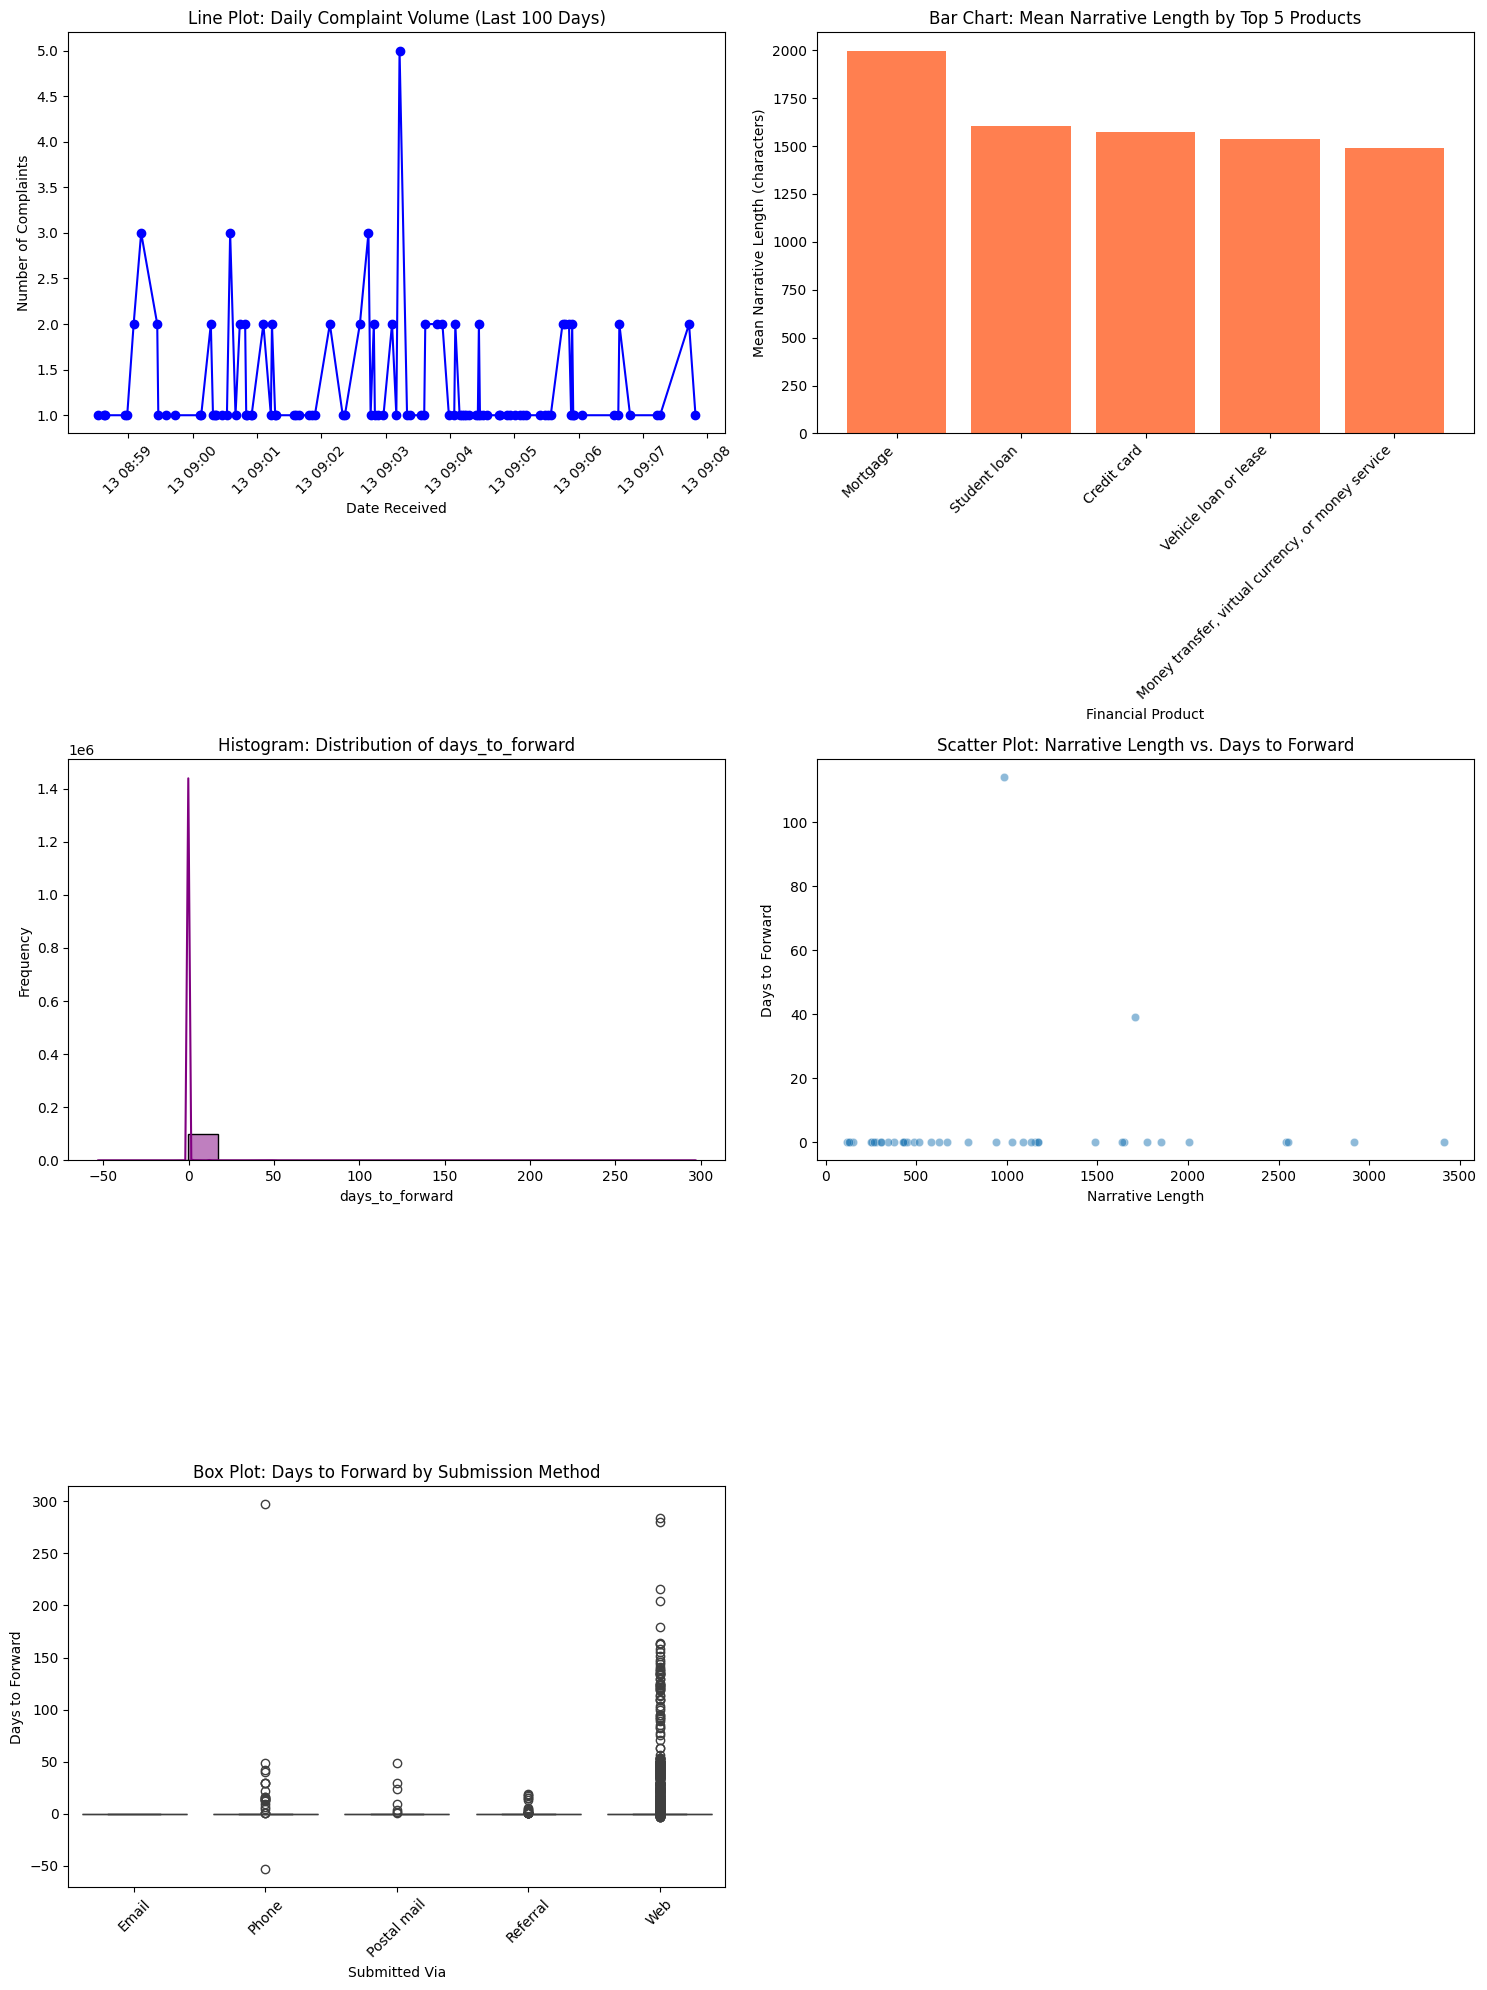

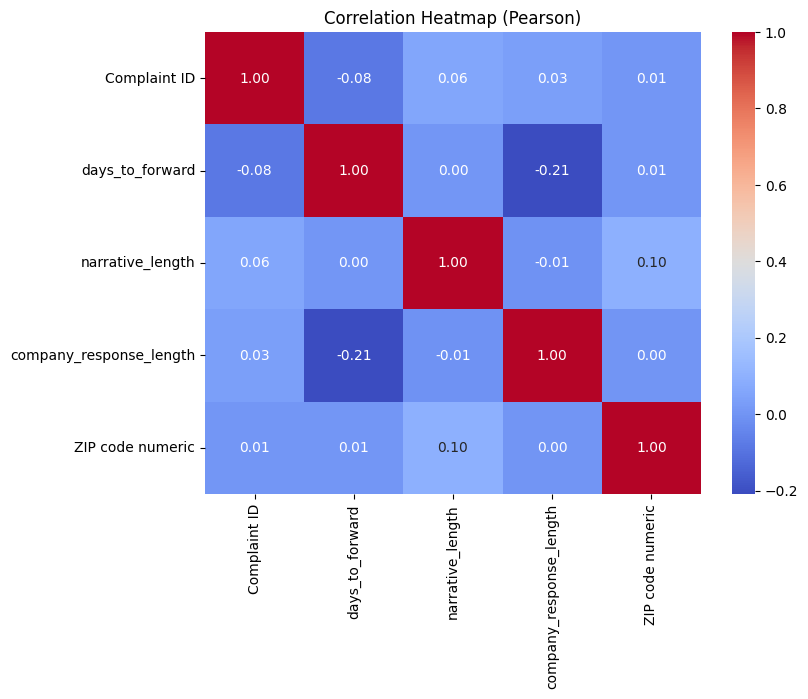

In [8]:
# Task 7 & 8: Visualizations
plt.figure(figsize=(15, 20))

# 1. Line Plot (Time Series of Complaints)
plt.subplot(3, 2, 1)
daily_counts = df.groupby('date_received').size().tail(100) # Plotting last 100 days for clarity
plt.plot(daily_counts.index, daily_counts.values, marker='o', linestyle='-', color='b')
plt.title('Line Plot: Daily Complaint Volume (Last 100 Days)')
plt.xlabel('Date Received')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)

# 2. Bar Chart (Mean narrative length by Category)
plt.subplot(3, 2, 2)
mean_lengths = df.groupby('Product')['narrative_length'].mean().sort_values(ascending=False).head(5)
plt.bar(mean_lengths.index.astype(str), mean_lengths.values, color='coral')
plt.title('Bar Chart: Mean Narrative Length by Top 5 Products')
plt.xlabel('Financial Product')
plt.ylabel('Mean Narrative Length (characters)')
plt.xticks(rotation=45, ha='right')

# 3. Histogram of most skewed column
plt.subplot(3, 2, 3)
sns.histplot(df[highest_skew_col].dropna(), bins=20, color='purple', kde=True)
plt.title(f'Histogram: Distribution of {highest_skew_col}')
plt.xlabel(highest_skew_col)
plt.ylabel('Frequency')

# 4. Scatter Plot
plt.subplot(3, 2, 4)
sns.scatterplot(x='narrative_length', y='days_to_forward', data=df.sample(2000), alpha=0.5) # Sampled for render speed
plt.title('Scatter Plot: Narrative Length vs. Days to Forward')
plt.xlabel('Narrative Length')
plt.ylabel('Days to Forward')

# 5. Box Plot
plt.subplot(3, 2, 5)
sns.boxplot(x='Submitted via', y='days_to_forward', data=df)
plt.title('Box Plot: Days to Forward by Submission Method')
plt.xlabel('Submitted Via')
plt.ylabel('Days to Forward')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
pearson_corr = numeric_df.corr()
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Pearson)')
plt.show()

In [10]:
# Task 9a: Imputation Strategy Comparison
top_2_skewed = skewness.abs().nlargest(2).index.tolist()
print(f"--- Top 2 Skewed Columns: {top_2_skewed} ---")

for col in top_2_skewed:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col} -> Mean: {mean_val:.2f} | Median: {median_val:.2f}")

    # Impute remaining nulls with chosen strategy (Median, due to high skew)
    df[col] = df[col].fillna(median_val)

print("\nNulls remaining in top 2 skewed columns after imputation:")
print(df[top_2_skewed].isnull().sum())

# Task 9b: Spearman Rank Correlation
spearman_corr = numeric_df.corr(method='spearman')
print("\n--- Spearman Rank Correlation Matrix ---")
display(spearman_corr)

# Calculate difference
diff_matrix = (spearman_corr - pearson_corr).abs()

# Find top 3 differences
stacked_diff = diff_matrix.unstack()
# Remove self-correlations (1.0 vs 1.0 = 0) and drop duplicates
stacked_diff = stacked_diff[stacked_diff.index.get_level_values(0) != stacked_diff.index.get_level_values(1)]
top_3_diffs = stacked_diff.drop_duplicates().nlargest(3)

print("\n--- Top 3 |Spearman - Pearson| Differences ---")
for index, diff_val in top_3_diffs.items():
    var1, var2 = index
    print(f"{var1} & {var2} -> Difference: {diff_val:.4f}")

# Task 9c: Grouped Aggregation
categorical_col = 'Submitted via'
numeric_col = 'days_to_forward'

grouped_stats = df.groupby(categorical_col, observed=True)[numeric_col].agg(['mean', 'std', 'count'])
print(f"\n--- Grouped Aggregation: {numeric_col} by {categorical_col} ---")
display(grouped_stats)

highest_mean_grp = grouped_stats['mean'].idxmax()
highest_std_grp = grouped_stats['std'].idxmax()
lowest_mean_grp = grouped_stats['mean'].idxmin()

#Preventing ZeroDivisionError by finding the lowest non-zero mean
min_mean = grouped_stats['mean'].min()
if min_mean == 0:
    # Filter for only means greater than 0, find the minimum of those
    non_zero_means = grouped_stats.loc[grouped_stats['mean'] > 0, 'mean']
    # If for some reason all are zero (highly unlikely), fallback to 1 to prevent crash
    min_mean = non_zero_means.min() if not non_zero_means.empty else 1.0

mean_ratio = grouped_stats['mean'].max() / min_mean

print(f"\nHighest Mean Group: {highest_mean_grp} ({grouped_stats.loc[highest_mean_grp, 'mean']:.2f})")
print(f"Highest Std Group: {highest_std_grp} ({grouped_stats.loc[highest_std_grp, 'std']:.2f})")
print(f"Ratio of Highest to Lowest (Non-Zero) Mean: {mean_ratio:.2f}")

--- Top 2 Skewed Columns: ['days_to_forward', 'company_response_length'] ---
days_to_forward -> Mean: 0.22 | Median: 0.00
company_response_length -> Mean: 94.94 | Median: 95.00

Nulls remaining in top 2 skewed columns after imputation:
days_to_forward            0
company_response_length    0
dtype: int64

--- Spearman Rank Correlation Matrix ---


,Complaint ID,days_to_forward,narrative_length,company_response_length,ZIP code numeric
Complaint ID,1.000000,-0.083027,0.042361,0.027805,0.011848
days_to_forward,-0.083027,1.000000,-0.003421,-0.139184,-0.000983
narrative_length,0.042361,-0.003421,1.000000,0.027385,0.086271
company_response_length,0.027805,-0.139184,0.027385,1.000000,-0.001731
ZIP code numeric,0.011848,-0.000983,0.086271,-0.001731,1.000000



--- Top 3 |Spearman - Pearson| Differences ---
days_to_forward & company_response_length -> Difference: 0.0700
narrative_length & company_response_length -> Difference: 0.0350
Complaint ID & narrative_length -> Difference: 0.0137

--- Grouped Aggregation: days_to_forward by Submitted via ---


,mean,std,count
Submitted via,,,
Email,0.000000,0.000000,26
Phone,4.051948,25.464006,154
Postal mail,0.804054,5.139759,148
Referral,0.891156,3.296177,147
Web,0.216459,3.935572,99469



Highest Mean Group: Phone (4.05)
Highest Std Group: Phone (25.46)
Ratio of Highest to Lowest (Non-Zero) Mean: 18.72


In [11]:
# Task10: Save the cleaned dataset
print("\nSaving cleaned data...")
df.to_csv('cleaned_data.csv', index=False)
print("Saved successfully to 'cleaned_data.csv'.")


Saving cleaned data...
Saved successfully to 'cleaned_data.csv'.
